# Construcción de máscaras

Todas las máscaras se guardan en convención **latitude ascendente (-90 -> 90)** y **longitude ascendente (-180 -> 180)**.

In [1]:
from pathlib import Path
import h5py
import json

import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

In [2]:
# Rutas
raw_dir = Path("/srv/read_only_data/final_datasets/")
masks_raw_dir = raw_dir / "masks"
output_dir = Path("/srv/read_only_data/final_datasets/masks")
output_dir.mkdir(parents=True, exist_ok=True)

climate_file = masks_raw_dir / "Beck_KG_V1_present_0p5.tif"
landcover_file = "/srv/read_only_data/raw/landcover/GLASS-GLC_7classes_2000.tif"
lai_qflag_h5 = masks_raw_dir / "../../THEIA_GEOV2/THEIA_GEOV2_R01_AVHRR_LAI_20200105.h5"
lai_monthly_nc = raw_dir / "lai_1982_2022_monthly_0.5deg.nc"

In [11]:
macro_labels = {
    0: "NoData",
    1: "Tropical",
    2: "Arid",
    3: "Temperate",
    4: "Cold",
    5: "Polar",
}

lc_labels = {
    0: "NoData",
    10: "Cropland",
    20: "Forest",
    30: "Grassland",
    40: "Shrubland",
    70: "Tundra",
    90: "Barren land",
    100: "Snow/Ice",
}

In [3]:
def show_da(da, title="", cmap="viridis", add_colorbar=True):
    plt.figure(figsize=(12, 5))
    da.plot(cmap=cmap, add_colorbar=add_colorbar)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def save_mask_npy(mask_da: xr.DataArray, output_path: str | Path):
    if tuple(mask_da.dims) != ("latitude", "longitude"):
        raise ValueError(f"Se esperaban dims ('latitude', 'longitude'). Recibido: {mask_da.dims}")

    lat = mask_da["latitude"].values
    lon = mask_da["longitude"].values

    if np.any(np.diff(lat) <= 0):
        raise ValueError("Latitude debe estar en orden ascendente antes de guardar.")
    if np.any(np.diff(lon) <= 0):
        raise ValueError("Longitude debe estar en orden ascendente antes de guardar.")

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(output_path, mask_da.values)


def standardize_2d_grid(da: xr.DataArray) -> xr.DataArray:
    rename = {}
    for old, new in [("lat", "latitude"), ("lon", "longitude"), ("x", "longitude"), ("y", "latitude")]:
        if old in da.dims or old in da.coords:
            rename[old] = new
    if rename:
        da = da.rename(rename)

    if tuple(da.dims) != ("latitude", "longitude"):
        da = da.transpose("latitude", "longitude")

    da = da.sortby("latitude").sortby("longitude")
    return da

## Climate

(360, 720)
[ 0  1  2  3  4  5  6  7  8  9 11 12 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30]


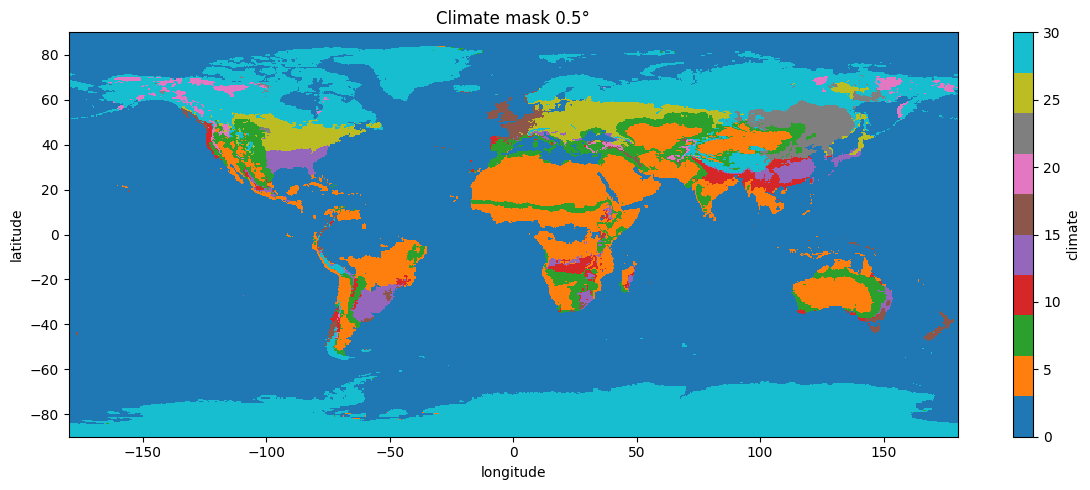

In [5]:
with rasterio.open(climate_file) as src:
    climate_raw = src.read(1)

# rasterio entrega north-up -> convertimos a latitude ascendente
climate_arr = np.flipud(climate_raw)

n_lat, n_lon = climate_arr.shape
latitude = np.linspace(-89.75, 89.75, n_lat, dtype=np.float32)
longitude = np.linspace(-179.75, 179.75, n_lon, dtype=np.float32)

climate_mask = xr.DataArray(
    climate_arr.astype(np.uint8),
    coords={"latitude": latitude, "longitude": longitude},
    dims=("latitude", "longitude"),
    name="climate",
).sortby("latitude").sortby("longitude")

print(climate_mask.shape)
print(np.unique(climate_mask.values))
show_da(climate_mask, "Climate mask 0.5°", cmap="tab10")

In [6]:
save_mask_npy(climate_mask, output_dir / "climate_mask_0p5_5classes.npy")
print("Guardado:", output_dir / "climate_mask_0p5_5classes.npy")

Guardado: /home/dani/github/profecia/data/masks/climate_mask_0p5_5classes.npy


## Land cover

(360, 720)
[  0  10  20  30  40  70  90 100]


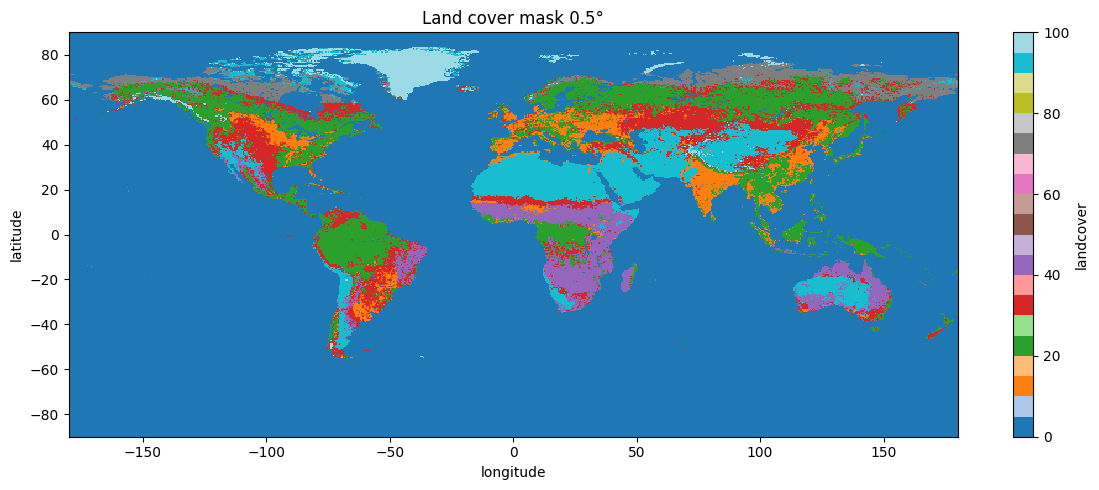

In [4]:
# grid objetivo 0.5°
n_lat, n_lon = 360, 720
latitude = np.linspace(-89.75, 89.75, n_lat, dtype=np.float32)
longitude = np.linspace(-179.75, 179.75, n_lon, dtype=np.float32)

dst_transform = from_bounds(-180.0, -90.0, 180.0, 90.0, n_lon, n_lat)
dst_crs = "EPSG:4326"

with rasterio.open(landcover_file) as src:
    src_arr = src.read(1)

    dst_arr = np.zeros((n_lat, n_lon), dtype=src_arr.dtype)

    reproject(
        source=src_arr,
        destination=dst_arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,   # importante para clases categóricas
    )

# rasterio deja north-up: fila 0 = norte
# nuestro pipeline quiere latitude ascendente: sur -> norte
dst_arr = np.flipud(dst_arr)

landcover_mask = xr.DataArray(
    dst_arr.astype(np.uint8),
    coords={"latitude": latitude, "longitude": longitude},
    dims=("latitude", "longitude"),
    name="landcover",
)

print(landcover_mask.shape)
print(np.unique(landcover_mask.values))
show_da(landcover_mask, "Land cover mask 0.5°", cmap="tab20")

In [5]:
save_mask_npy(landcover_mask, output_dir / "landcover_mask_0p5_7classes.npy")
print("Guardado:", output_dir / "landcover_mask_0p5_7classes.npy")

PermissionError: [Errno 13] Permission denied: '/srv/read_only_data/final_datasets/masks/landcover_mask_0p5_7classes.npy'

## Per-class landcover masks

In [ ]:
# Dictionary mapping landcover class codes to names
lc_classes = {
    10: "cropland",
    20: "forest",
    30: "grassland",
    40: "shrubland",
    70: "tundra",
    90: "barren",
    100: "snow_ice",
}

# Generate and save per-class masks
print("=" * 60)
print("Generating per-class landcover masks")
print("=" * 60)

for lc_code, lc_name in lc_classes.items():
    # Create binary mask for this class
    mask = (landcover_mask == lc_code).astype(np.uint8).rename(f"landcover_{lc_name}")
    pixels = int(mask.sum())
    
    # Save mask
    output_file = output_dir / f"landcover_{lc_name}_0p5deg.npy"
    save_mask_npy(mask, output_file)
    print(f"{lc_name:12s}: {pixels:7d} pixels → {output_file.name}")

print("=" * 60)

## Máscaras individuales por clase

In [ ]:
# Load and visualize all per-class landcover masks with individual maps
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define the landcover classes
lc_classes_display = {
    "Cropland": (landcover_mask == 10).astype(np.uint8),
    "Forest": (landcover_mask == 20).astype(np.uint8),
    "Grassland": (landcover_mask == 30).astype(np.uint8),
    "Shrubland": (landcover_mask == 40).astype(np.uint8),
    "Tundra": (landcover_mask == 70).astype(np.uint8),
    "Barren land": (landcover_mask == 90).astype(np.uint8),
    "Snow/Ice": (landcover_mask == 100).astype(np.uint8),
}

# Create figure with subplots (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()

# Color map for binary masks: white for 0, color for 1
class_colors = [
    "Oranges",      # Cropland
    "Greens",       # Forest
    "YlGn",         # Grassland
    "BuGn",         # Shrubland
    "Blues",        # Tundra
    "Greys",        # Barren land
    "Purples",      # Snow/Ice
]

# Plot each class mask
for idx, (class_name, mask_data) in enumerate(lc_classes_display.items()):
    ax = axes[idx]
    im = ax.imshow(np.flipud(mask_data), cmap=class_colors[idx], vmin=0, vmax=1)
    
    pixel_count = int(mask_data.sum())
    percentage = (pixel_count / mask_data.size) * 100
    
    ax.set_title(f"{class_name}\n{pixel_count:,} pixels ({percentage:.2f}%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3, linestyle="--")

# Hide the last empty subplot
axes[-1].axis("off")

plt.suptitle("Per-class Landcover Masks (0.5° resolution) - Individual Maps", fontsize=16, fontweight="bold", y=0.995)
plt.show()

print("\n" + "=" * 70)
print("Per-class Landcover Masks Summary")
print("=" * 70)
for class_name, mask_data in lc_classes_display.items():
    pixel_count = int(mask_data.sum())
    percentage = (pixel_count / mask_data.size) * 100
    print(f"{class_name:15s}: {pixel_count:7,} pixels ({percentage:6.2f}%)")
print("=" * 70)

## Snow and ice mask desde land cover


Snow/ice pixels: 5495


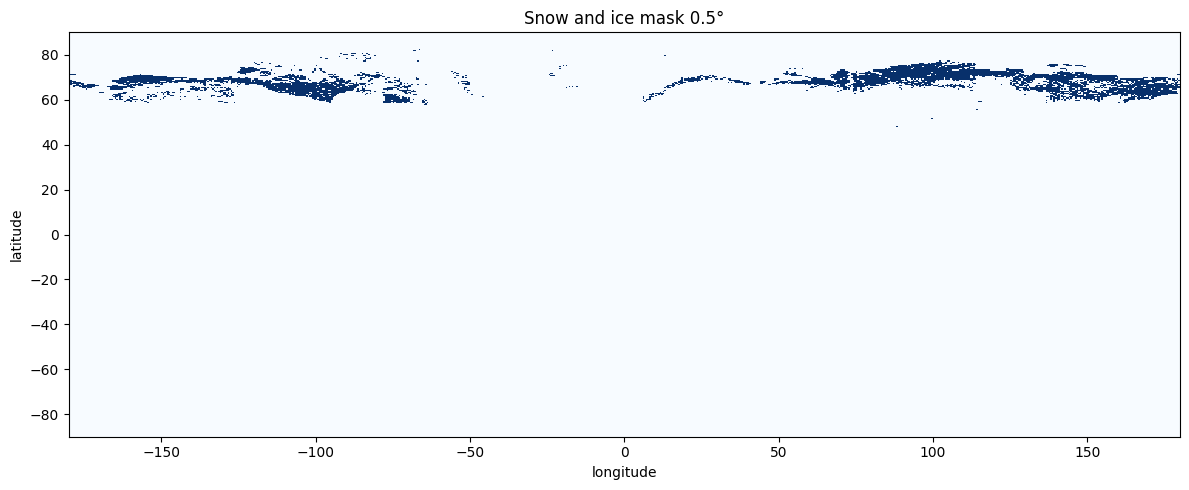

In [14]:
snow_ice_mask = (landcover_mask == 70).astype(np.uint8).rename("snow_ice")
print("Snow/ice pixels:", int(snow_ice_mask.sum()))
show_da(snow_ice_mask, "Snow and ice mask 0.5°", cmap="Blues", add_colorbar=False)


In [19]:
save_mask_npy(snow_ice_mask, "snow_ice_mask_0p5deg.npy")
print("Guardado:", "snow_ice_mask_0p5deg.npy")


Guardado: snow_ice_mask_0p5deg.npy


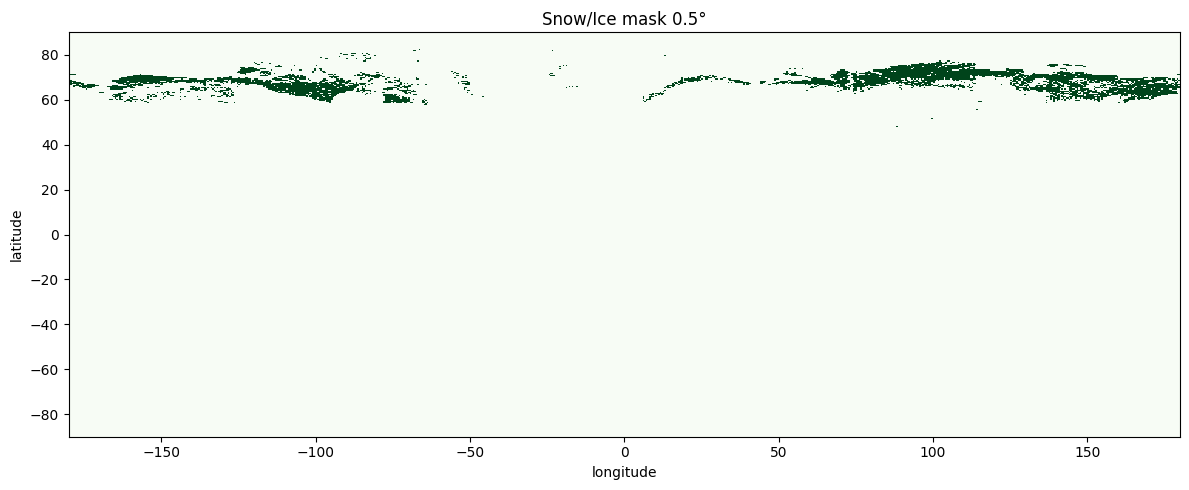

In [20]:
show_da(snow_ice_mask, "Snow/Ice mask 0.5°", cmap="Greens", add_colorbar=False)


## EBF y BS desde LAI-QFLAG

In [13]:
with h5py.File(lai_qflag_h5, "r") as f:
    qflag = np.array(f["LAI-QFLAG"])

print("QFLAG shape:", qflag.shape, "dtype:", qflag.dtype)

QFLAG shape: (3600, 7200) dtype: uint16


In [14]:
bit_ebf = 11
bit_bs = 12

qflag_uint = qflag.astype(np.uint16)
is_ebf = ((qflag_uint >> bit_ebf) & 1).astype(np.float32)
is_bs = ((qflag_uint >> bit_bs) & 1).astype(np.float32)

n_lat_005, n_lon_005 = qflag.shape
latitude_005_desc = np.linspace(89.975, -89.975, n_lat_005, dtype=np.float32)
longitude_005 = np.linspace(-179.975, 179.975, n_lon_005, dtype=np.float32)

ebf_da_005 = xr.DataArray(
    is_ebf,
    coords={"latitude": latitude_005_desc, "longitude": longitude_005},
    dims=("latitude", "longitude"),
    name="ebf_005",
)
bs_da_005 = xr.DataArray(
    is_bs,
    coords={"latitude": latitude_005_desc, "longitude": longitude_005},
    dims=("latitude", "longitude"),
    name="bs_005",
)

factor = 10
ebf_fraction_05 = ebf_da_005.coarsen(latitude=factor, longitude=factor, boundary="exact").mean()
bs_fraction_05 = bs_da_005.coarsen(latitude=factor, longitude=factor, boundary="exact").mean()

ebf_mask = (ebf_fraction_05 >= 0.5).astype(np.uint8).rename("ebf")
bs_mask = (bs_fraction_05 >= 0.5).astype(np.uint8).rename("bs")

# Clave: orden ascendente final del pipeline
ebf_mask = ebf_mask.sortby("latitude").sortby("longitude")
bs_mask = bs_mask.sortby("latitude").sortby("longitude")

print("EBF pixels:", int(ebf_mask.sum()))
print("BS pixels:", int(bs_mask.sum()))

EBF pixels: 2719
BS pixels: 4892


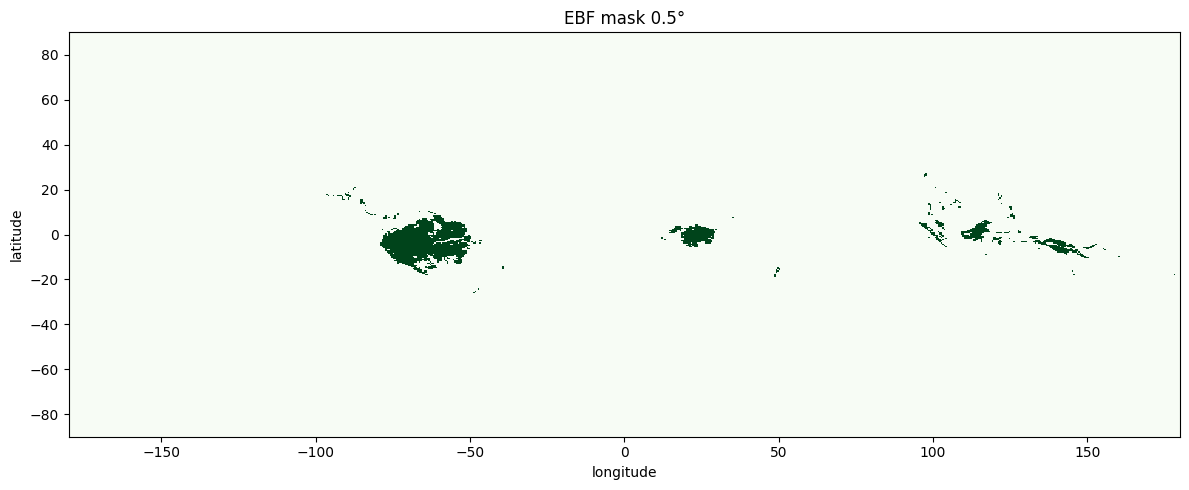

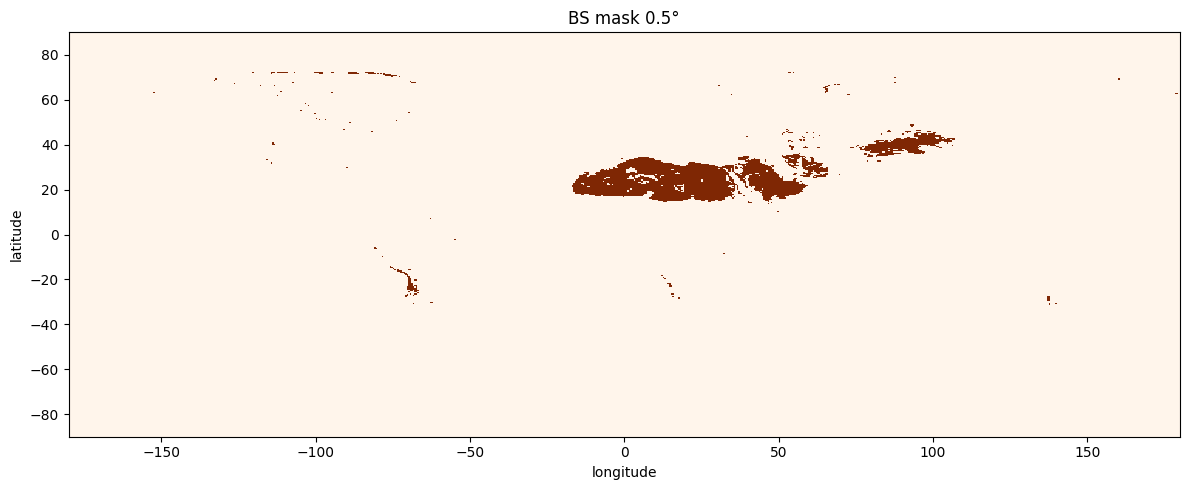

In [15]:
show_da(ebf_mask, "EBF mask 0.5°", cmap="Greens", add_colorbar=False)
show_da(bs_mask, "BS mask 0.5°", cmap="Oranges", add_colorbar=False)

In [16]:
save_mask_npy(ebf_mask, output_dir / "ebf_mask_0p5deg.npy")
save_mask_npy(bs_mask, output_dir / "bs_mask_0p5deg.npy")
print("Guardado:", output_dir / "ebf_mask_0p5deg.npy")
print("Guardado:", output_dir / "bs_mask_0p5deg.npy")

Guardado: /home/dani/github/profecia/data/masks/ebf_mask_0p5deg.npy
Guardado: /home/dani/github/profecia/data/masks/bs_mask_0p5deg.npy


## Land mask desde LAI monthly 0.5°

In [17]:
ds = xr.open_dataset(lai_monthly_nc)
rename = {}
for old, new in [("lat", "latitude"), ("lon", "longitude"), ("x", "longitude"), ("y", "latitude")]:
    if old in ds.dims or old in ds.coords:
        rename[old] = new
if rename:
    ds = ds.rename(rename)

var_name = list(ds.data_vars)[0]
LAI = ds[var_name].transpose("time", "latitude", "longitude").sortby("time").sortby("latitude").sortby("longitude")
LAI = LAI.astype("float32")

print(LAI.shape)
print(float(LAI.latitude.min()), float(LAI.latitude.max()))
print(float(LAI.longitude.min()), float(LAI.longitude.max()))

(492, 360, 720)
-90.0 89.5
-180.0 179.5


Land pixels: 62665
Land fraction: 0.2417631172839506


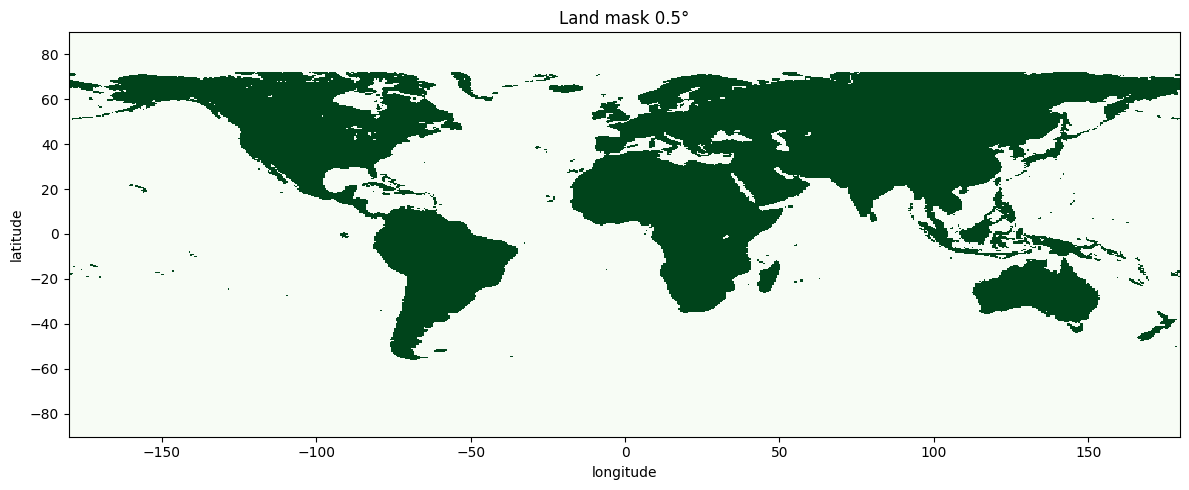

In [18]:
# Tierra = píxeles con dato válido en todos los timesteps
land_mask = LAI.notnull().all(dim="time").astype(np.uint8).rename("land")
print("Land pixels:", int(land_mask.sum()))
print("Land fraction:", float(land_mask.mean()))
show_da(land_mask, "Land mask 0.5°", cmap="Greens", add_colorbar=False)

In [19]:
save_mask_npy(land_mask, output_dir / "land_mask_0p5deg.npy")
print("Guardado:", output_dir / "land_mask_0p5deg.npy")
ds.close()

Guardado: /home/dani/github/profecia/data/masks/land_mask_0p5deg.npy


## Comprobación final

In [ ]:
for filename in [
    "climate_mask_0p5_5classes.npy",
    "landcover_mask_0p5_7classes.npy",
    "ebf_mask_0p5deg.npy",
    "bs_mask_0p5deg.npy",
    "snow_ice_mask_0p5deg.npy",
    "land_mask_0p5deg.npy",
    # Per-class landcover masks
    "landcover_cropland_0p5deg.npy",
    "landcover_forest_0p5deg.npy",
    "landcover_grassland_0p5deg.npy",
    "landcover_shrubland_0p5deg.npy",
    "landcover_tundra_0p5deg.npy",
    "landcover_barren_0p5deg.npy",
    "landcover_snow_ice_0p5deg.npy",
]:
    arr = np.load(output_dir / filename)
    print(filename, arr.shape, arr.dtype, np.unique(arr)[:10])

climate_mask_0p5_5classes.npy (360, 720) uint8 [0 1 2 3 4 5 6 7 8 9]
landcover_mask_0p5_7classes.npy (360, 720) uint8 [  0  10  20  30  40  70  90 100]
ebf_mask_0p5deg.npy (360, 720) uint8 [0 1]
bs_mask_0p5deg.npy (360, 720) uint8 [0 1]
land_mask_0p5deg.npy (360, 720) uint8 [0 1]


In [ ]:
# Validation: per-class masks coverage and non-overlaps
print("=" * 70)
print("VALIDATION: Per-class landcover masks")
print("=" * 70)

lc_classes_verify = {
    10: "cropland",
    20: "forest",
    30: "grassland",
    40: "shrubland",
    70: "tundra",
    90: "barren",
    100: "snow_ice",
}

# Load all per-class masks
class_masks = {}
for code, name in lc_classes_verify.items():
    path = output_dir / f"landcover_{name}_0p5deg.npy"
    class_masks[name] = np.load(path)
    assert class_masks[name].dtype == np.uint8, f"{name} mask is not uint8"
    assert np.all((class_masks[name] == 0) | (class_masks[name] == 1)), f"{name} mask contains non-binary values"
    print(f"✓ {name:12s} mask is binary, {int(class_masks[name].sum()):7d} pixels")

# Check for overlaps: sum of all class masks should equal non-zero pixels in original landcover
landcover_orig = np.load(output_dir / "landcover_mask_0p5_7classes.npy")
sum_class_masks = np.sum([m for m in class_masks.values()], axis=0)
sum_original = (landcover_orig != 0).astype(np.uint8)

# Verify coverage
coverage = np.allclose(sum_class_masks, sum_original)
print(f"\n✓ Coverage OK: sum(all_classes) == (landcover != 0): {coverage}")

# Check for overlaps
overlaps = (sum_class_masks > 1).sum()
print(f"✓ No overlaps: {overlaps} pixels assigned to multiple classes (should be 0)")

if overlaps == 0:
    print("\n✅ All per-class landcover masks are valid and consistent!")
else:
    print(f"\n⚠️ WARNING: Found {overlaps} overlapping pixels!")

print("=" * 70)

In [ ]:
metadata = {
    "convention": {
        "latitude": "ascending",
        "longitude": "ascending",
        "grid": "0.5deg",
        "extent": {
            "lat_min": -90,
            "lat_max": 90,
            "lon_min": -180,
            "lon_max": 180,
        },
    },
    "files": {
        "climate": "climate_mask_0p5_5classes.npy",
        "landcover": "landcover_mask_0p5_7classes.npy",
        "ebf": "ebf_mask_0p5deg.npy",
        "bs": "bs_mask_0p5deg.npy",
        "snow_ice": "snow_ice_mask_0p5deg.npy",
        "land": "land_mask_0p5deg.npy",
        # Per-class landcover masks
        "landcover_cropland": "landcover_cropland_0p5deg.npy",
        "landcover_forest": "landcover_forest_0p5deg.npy",
        "landcover_grassland": "landcover_grassland_0p5deg.npy",
        "landcover_shrubland": "landcover_shrubland_0p5deg.npy",
        "landcover_tundra": "landcover_tundra_0p5deg.npy",
        "landcover_barren": "landcover_barren_0p5deg.npy",
        "landcover_snow_ice": "landcover_snow_ice_0p5deg.npy",
    },
    "masks": {
        "climate": {
            "type": "categorical",
            "description": "Macro climate zones",
            "nodata_code": 0,
            "valid_codes": [1, 2, 3, 4, 5],
            "labels": {
                0: "NoData",
                1: "Tropical",
                2: "Arid",
                3: "Temperate",
                4: "Cold",
                5: "Polar",
            },
        },
        "landcover": {
            "type": "categorical",
            "description": "Land cover classes",
            "nodata_code": 0,
            "valid_codes": [10, 20, 30, 40, 70, 90, 100],
            "labels": {
                0: "NoData",
                10: "Cropland",
                20: "Forest",
                30: "Grassland",
                40: "Shrubland",
                70: "Tundra",
                90: "Barren land",
                100: "Snow/Ice",
            },
        },
        "ebf": {
            "type": "binary",
            "description": "Evergreen Broadleaf Forest mask",
            "true_meaning": "EBF pixel (to exclude)",
            "false_meaning": "Non-EBF pixel",
        },
        "bs": {
            "type": "binary",
            "description": "Bare Soil (desert) mask",
            "true_meaning": "Bare soil pixel (to exclude)",
            "false_meaning": "Non-bare-soil pixel",
        },
        "snow_ice": {
            "type": "binary",
            "description": "Snow and ice mask derived from land cover",
            "true_meaning": "Snow and ice pixel (to exclude)",
            "false_meaning": "Non-snow-and-ice pixel",
        },
        "land": {
            "type": "binary",
            "description": "Land mask derived from LAI",
            "true_meaning": "Land pixel",
            "false_meaning": "Water / invalid pixel",
        },
        # Per-class landcover masks (binary)
        "landcover_cropland": {
            "type": "binary",
            "description": "Cropland class from land cover",
            "landcover_code": 10,
            "true_meaning": "Cropland pixel",
            "false_meaning": "Non-cropland pixel",
        },
        "landcover_forest": {
            "type": "binary",
            "description": "Forest class from land cover",
            "landcover_code": 20,
            "true_meaning": "Forest pixel",
            "false_meaning": "Non-forest pixel",
        },
        "landcover_grassland": {
            "type": "binary",
            "description": "Grassland class from land cover",
            "landcover_code": 30,
            "true_meaning": "Grassland pixel",
            "false_meaning": "Non-grassland pixel",
        },
        "landcover_shrubland": {
            "type": "binary",
            "description": "Shrubland class from land cover",
            "landcover_code": 40,
            "true_meaning": "Shrubland pixel",
            "false_meaning": "Non-shrubland pixel",
        },
        "landcover_tundra": {
            "type": "binary",
            "description": "Tundra class from land cover",
            "landcover_code": 70,
            "true_meaning": "Tundra pixel",
            "false_meaning": "Non-tundra pixel",
        },
        "landcover_barren": {
            "type": "binary",
            "description": "Barren land class from land cover",
            "landcover_code": 90,
            "true_meaning": "Barren land pixel",
            "false_meaning": "Non-barren-land pixel",
        },
        "landcover_snow_ice": {
            "type": "binary",
            "description": "Snow/Ice class from land cover",
            "landcover_code": 100,
            "true_meaning": "Snow/Ice pixel",
            "false_meaning": "Non-snow-ice pixel",
        },
    },
}

Guardado: /home/dani/github/profecia/data/masks/mask_metadata.json
